In [1]:

import pandas as pd
from sklearn.preprocessing import StandardScaler


In [2]:

# 1. Load the data
df = pd.read_csv('customers.csv')

# 2. Data Cleaning: Drop the 'Name' column as it's just an ID
# We keep a copy of the original for reference later
df_features = df.drop(columns=['Name'])

# 3. Data Scaling Pipeline
# Hierarchical clustering relies on distance, so scaling is critical
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)

# Convert back to a DataFrame for easier handling
df_scaled = pd.DataFrame(scaled_data, columns=df_features.columns)

print("Original Data (first 3 rows):")
display(df_features.head(3))

print("\nScaled Data (first 3 rows):")
display(df_scaled.head(3))

Original Data (first 3 rows):


,AverageSpend,AverageFrequency
0,88.0,48.0
1,95.0,45.5
2,92.0,46.8



Scaled Data (first 3 rows):


,AverageSpend,AverageFrequency
0,1.023625,1.083185
1,1.259135,0.947685
2,1.158202,1.018145


## Cell 2: Dendrogram Visualization
    Run this cell to generate the dendrogram. This visual tree will help you decide how many clusters exist based on the vertical heights of the branches before they merge.

In [4]:

import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch


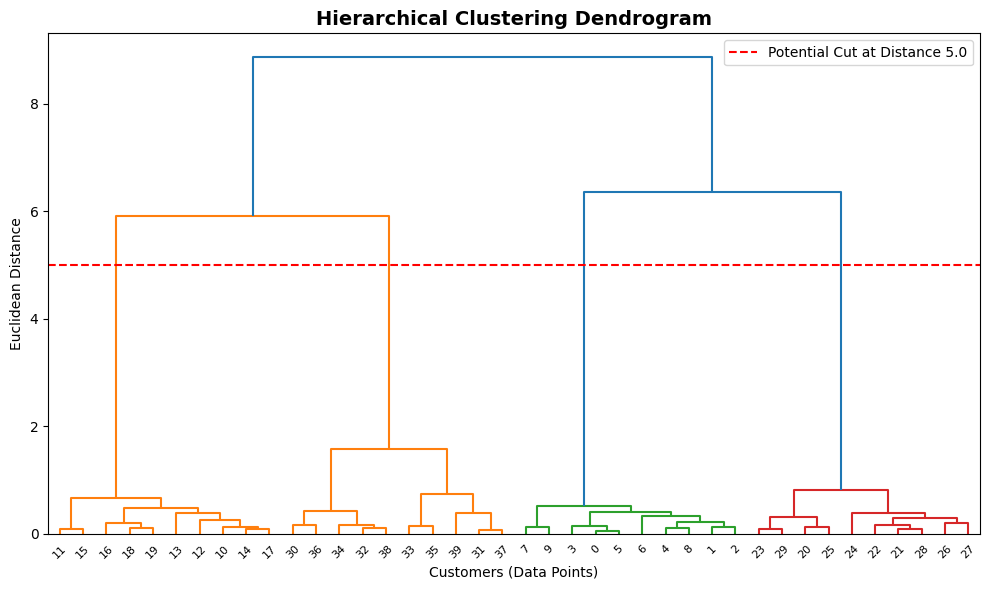

In [5]:

plt.figure(figsize=(10, 6))
plt.title('Hierarchical Clustering Dendrogram', fontsize=14, fontweight='bold')
plt.xlabel('Customers (Data Points)')
plt.ylabel('Euclidean Distance')

# Generate the linkage matrix using Ward's method
linkage_matrix = sch.linkage(df_scaled, method='ward')

# Plot the dendrogram
dendrogram = sch.dendrogram(linkage_matrix)

# ADDING A CUT LINE (Optional visual aid)
# You can adjust 'y' to see where a horizontal cut would intersect the tree.
# For example, if y=5 intersects 3 vertical lines, you have 3 clusters.
cut_distance = 5.0  
plt.axhline(y=cut_distance, color='r', linestyle='--', label=f'Potential Cut at Distance {cut_distance}')
plt.legend()

plt.tight_layout()
plt.show()

## Cell 3: Applying the Cut and Extracting Clusters
Once you review the dendrogram from Cell 2, you can specify how many clusters you want to form in this cell.

In [7]:
# --- CELL 3: Training the Model with the Chosen Cut ---
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns


In [12]:

# Set the number of clusters based on your dendrogram observation
# (e.g., if the longest vertical lines can be cut into 3 sections, choose 3)
OPTIMAL_CLUSTERS = 4


# Initialize and train the Agglomerative model
hc_model = AgglomerativeClustering(
    n_clusters=OPTIMAL_CLUSTERS, 
    metric='euclidean', 
    linkage='ward'
)

# Fit the model and get the cluster labels
cluster_labels = hc_model.fit_predict(df_scaled)


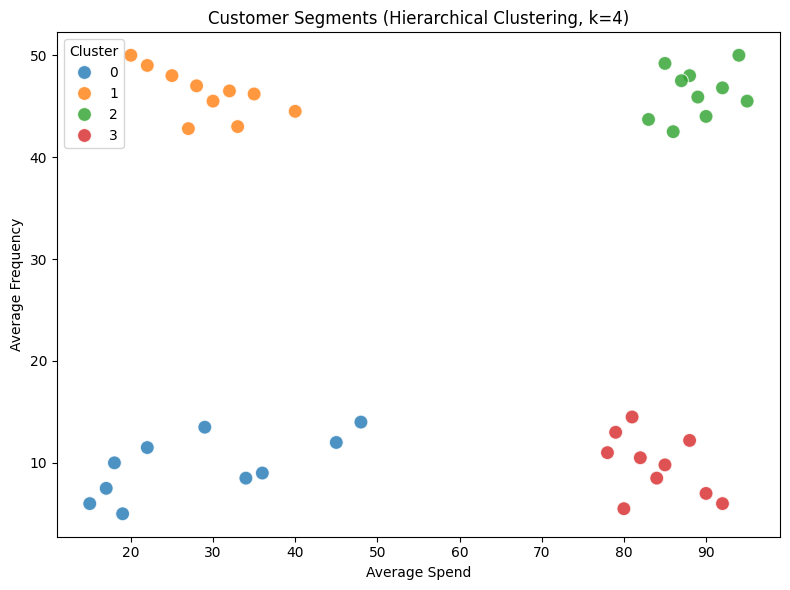

,Name,AverageSpend,AverageFrequency,Cluster
0,Customer1,88.0,48.0,2
1,Customer2,95.0,45.5,2
2,Customer3,92.0,46.8,2
3,Customer4,85.0,49.2,2
4,Customer5,90.0,44.0,2


In [13]:

# Add the cluster labels back to the ORIGINAL dataframe for business interpretation
df['Cluster'] = cluster_labels

# Visualize the final clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, 
    x='AverageSpend', 
    y='AverageFrequency', 
    hue='Cluster', 
    palette='tab10', 
    s=100, 
    alpha=0.8
)

plt.title(f'Customer Segments (Hierarchical Clustering, k={OPTIMAL_CLUSTERS})')
plt.xlabel('Average Spend')
plt.ylabel('Average Frequency')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Display the first few rows with their assigned cluster
display(df[['Name', 'AverageSpend', 'AverageFrequency', 'Cluster']].head())

In [14]:
# --- CELL 4: Saving the Model and the Results ---
import joblib


In [15]:

# 1. Save the model object to a file
# This saves the state of the tree and the labels it generated
model_filename = 'hierarchical_model.pkl'
joblib.dump(hc_model, model_filename)
print(f"Model successfully saved as {model_filename}")

# 2. Save the dataset with the new 'Cluster' column
# This is highly recommended for hierarchical clustering
data_filename = 'customers_with_clusters.csv'
df.to_csv(data_filename, index=False)
print(f"Clustered data successfully saved as {data_filename}")

Model successfully saved as hierarchical_model.pkl
Clustered data successfully saved as customers_with_clusters.csv


In [16]:
# --- CELL 5: Cluster Profiling & Cross-Tab Analysis ---

# Group by the 'Cluster' column and aggregate the data
cluster_profile = df.groupby('Cluster').agg(
    CustomerCount=('Name', 'count'),
    MeanSpend=('AverageSpend', 'mean'),
    MinSpend=('AverageSpend', 'min'),
    MaxSpend=('AverageSpend', 'max'),
    MeanFreq=('AverageFrequency', 'mean'),
    MinFreq=('AverageFrequency', 'min'),
    MaxFreq=('AverageFrequency', 'max')
).round(2).reset_index()

# Display the grouped summary table
print("Cluster Profiling Summary:")
display(cluster_profile)

Cluster Profiling Summary:


,Cluster,CustomerCount,MeanSpend,MinSpend,MaxSpend,MeanFreq,MinFreq,MaxFreq
0,0,10,28.3,15.0,48.0,9.70,5.0,14.0
1,1,10,29.2,20.0,40.0,46.25,42.8,50.0
2,2,10,88.9,83.0,95.0,46.31,42.5,50.0
3,3,10,83.9,78.0,92.0,9.80,5.5,14.5


In [17]:
# Define the mapping dictionary based on the analysis
persona_mapping = {
    0: 'Low-Engagement Casuals',
    1: 'Frequent Bargain Hunters',
    2: 'VIP Champions',
    3: 'Big-Ticket Occasional Buyers'
}

# Map the cluster numbers to the new meaningful names
df['CustomerPersona'] = df['Cluster'].map(persona_mapping)

# Display the final dataset to verify
display(df[['Name', 'AverageSpend', 'AverageFrequency', 'Cluster', 'CustomerPersona']].head(10))

,Name,AverageSpend,AverageFrequency,Cluster,CustomerPersona
0,Customer1,88.0,48.0,2,VIP Champions
1,Customer2,95.0,45.5,2,VIP Champions
2,Customer3,92.0,46.8,2,VIP Champions
3,Customer4,85.0,49.2,2,VIP Champions
4,Customer5,90.0,44.0,2,VIP Champions
5,Customer6,87.0,47.5,2,VIP Champions
6,Customer7,94.0,50.0,2,VIP Champions
7,Customer8,83.0,43.7,2,VIP Champions
8,Customer9,89.0,45.9,2,VIP Champions
9,Customer10,86.0,42.5,2,VIP Champions


In [18]:
# --- CELL 6: Model Evaluation (Unsupervised Metrics) ---
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd


In [19]:

# Note: We evaluate using the scaled data (df_scaled) because 
# distance metrics are highly sensitive to unscaled numbers.

# 1. Calculate the metrics
sil_score = silhouette_score(df_scaled, cluster_labels)
ch_score = calinski_harabasz_score(df_scaled, cluster_labels)
db_score = davies_bouldin_score(df_scaled, cluster_labels)

# 2. Display the results in a readable format
evaluation_results = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Calinski-Harabasz Index', 'Davies-Bouldin Index'],
    'Score': [sil_score, ch_score, db_score],
    'What it means': [
        'How well apart the clusters are (-1 to 1). Closer to 1 is better.',
        'Ratio of variance between clusters to variance within clusters. Higher is better.',
        'Average similarity between clusters. Closer to 0 is better.'
    ]
})

print("=== Clustering Evaluation Metrics ===")
display(evaluation_results)

=== Clustering Evaluation Metrics ===


,Metric,Score,What it means
0,Silhouette Score,0.809746,How well apart the clusters are (-1 to 1). Clo...
1,Calinski-Harabasz Index,304.542341,Ratio of variance between clusters to variance...
2,Davies-Bouldin Index,0.275757,Average similarity between clusters. Closer to...
